We build a decision tree classifier that predicts whether a passenger survived
the Titanic disaster

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
)
import matplotlib.pyplot as plt

RANDOM_STATE = 42

## 1. Load and inspect the data
Read `titanic.csv`, confirm the target is `Survived` (1 = survived, 0 = died), and
look at how much data is missing.

In [4]:
df = pd.read_csv("titanic.csv")
print("Shape:", df.shape)
df.head()

Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
print("Survival rate: {:.1%}".format(df["Survived"].mean()))
print("\nSurvived counts:")
print(df["Survived"].value_counts())
print("\nMissing values per column:")
print(df.isna().sum())

Survival rate: 38.4%

Survived counts:
Survived
0    549
1    342
Name: count, dtype: int64

Missing values per column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


## 2. Choose the parameters and clean them
We predict Survived from these parameters:


We drop identifier columns (`PassengerId`, `Name`, `Ticket`, `Cabin`)
that are not usable parameters. We fill the missing `Age` with the median, the two
missing `Embarked` values with the most common port, and encode the categorical
parameters (`Sex`, `Embarked`) as integers so the tree can split on them.

In [4]:
features = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]
data = df[features + ["Survived"]].copy()

# Impute missing values
data["Age"] = data["Age"].fillna(data["Age"].median())
data["Embarked"] = data["Embarked"].fillna(data["Embarked"].mode()[0])

# Encode categoricals as integers
data["Sex"] = data["Sex"].map({"male": 0, "female": 1})
data["Embarked"] = data["Embarked"].map({"S": 0, "C": 1, "Q": 2})

print("Missing after cleaning:", int(data.isna().sum().sum()))
data.head()

Missing after cleaning: 0


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Survived
0,3,0,22.0,1,0,7.2500,0,0
1,1,1,38.0,1,0,71.2833,1,1
2,3,1,26.0,0,0,7.9250,0,1
3,1,1,35.0,1,0,53.1000,0,1
4,3,0,35.0,0,0,8.0500,0,0


## 3. Define the variables and split the data


In [5]:
X = data[features]
y = data["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
print("Train:", X_train.shape[0], "passengers | Test:", X_test.shape[0], "passengers")
print("Train survival rate: {:.1%} | Test survival rate: {:.1%}".format(
    y_train.mean(), y_test.mean()))

Train: 712 passengers | Test: 179 passengers
Train survival rate: 38.3% | Test survival rate: 38.5%


## 4. Fit the decision tree

In [6]:
clf = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=10,
    criterion="gini",
    random_state=RANDOM_STATE,
)
clf.fit(X_train, y_train)
print("Tree trained. Depth:", clf.get_depth(), "| Leaves:", clf.get_n_leaves())

Tree trained. Depth: 4 | Leaves: 13


## 5. Evaluate

In [7]:
y_pred = clf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy : {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall   : {rec:.3f}")
print(f"F1 score : {f1:.3f}")

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion matrix [rows=actual, cols=predicted]:")
print(pd.DataFrame(cm, index=["died", "survived"], columns=["pred died", "pred survived"]))
print("\n", classification_report(y_test, y_pred, target_names=["died", "survived"]))

Accuracy : 0.777
Precision: 0.809
Recall   : 0.551
F1 score : 0.655

Confusion matrix [rows=actual, cols=predicted]:
          pred died  pred survived
died            101              9
survived         31             38

               precision    recall  f1-score   support

        died       0.77      0.92      0.83       110
    survived       0.81      0.55      0.66        69

    accuracy                           0.78       179
   macro avg       0.79      0.73      0.74       179
weighted avg       0.78      0.78      0.77       179



## 6. Compare to a baseline
A trivial baseline predicts the majority class (everyone dies) for every passenger.
The tree should beat it clearly.

In [8]:
baseline_pred = np.zeros_like(y_test)  # predict "died" for everyone
baseline_acc = accuracy_score(y_test, baseline_pred)
print(f"Majority-class baseline accuracy: {baseline_acc:.3f}")
print(f"Decision tree accuracy         : {acc:.3f}")
print(f"Improvement                    : +{acc - baseline_acc:.3f}")

Majority-class baseline accuracy: 0.615
Decision tree accuracy         : 0.777
Improvement                    : +0.162


## 7. Which parameters matter most?

In [9]:
importances = pd.Series(clf.feature_importances_, index=features).sort_values(ascending=False)
print(importances.round(3))

Sex         0.598
Pclass      0.203
Age         0.089
Fare        0.070
Embarked    0.039
Parch       0.001
SibSp       0.000
dtype: float64


## 8. Read the tree

In [10]:
print(export_text(clf, feature_names=features))

|--- Sex <= 0.50
|   |--- Age <= 3.50
|   |   |--- class: 1
|   |--- Age >  3.50
|   |   |--- Pclass <= 1.50
|   |   |   |--- Fare <= 26.14
|   |   |   |   |--- class: 0
|   |   |   |--- Fare >  26.14
|   |   |   |   |--- class: 0
|   |   |--- Pclass >  1.50
|   |   |   |--- Fare <= 51.70
|   |   |   |   |--- class: 0
|   |   |   |--- Fare >  51.70
|   |   |   |   |--- class: 0
|--- Sex >  0.50
|   |--- Pclass <= 2.50
|   |   |--- Fare <= 28.86
|   |   |   |--- Age <= 37.00
|   |   |   |   |--- class: 1
|   |   |   |--- Age >  37.00
|   |   |   |   |--- class: 1
|   |   |--- Fare >  28.86
|   |   |   |--- Parch <= 1.50
|   |   |   |   |--- class: 1
|   |   |   |--- Parch >  1.50
|   |   |   |   |--- class: 1
|   |--- Pclass >  2.50
|   |   |--- Embarked <= 0.50
|   |   |   |--- Fare <= 17.25
|   |   |   |   |--- class: 0
|   |   |   |--- Fare >  17.25
|   |   |   |   |--- class: 0
|   |   |--- Embarked >  0.50
|   |   |   |--- Fare <= 8.08
|   |   |   |   |--- class: 1
|   |   |   |---

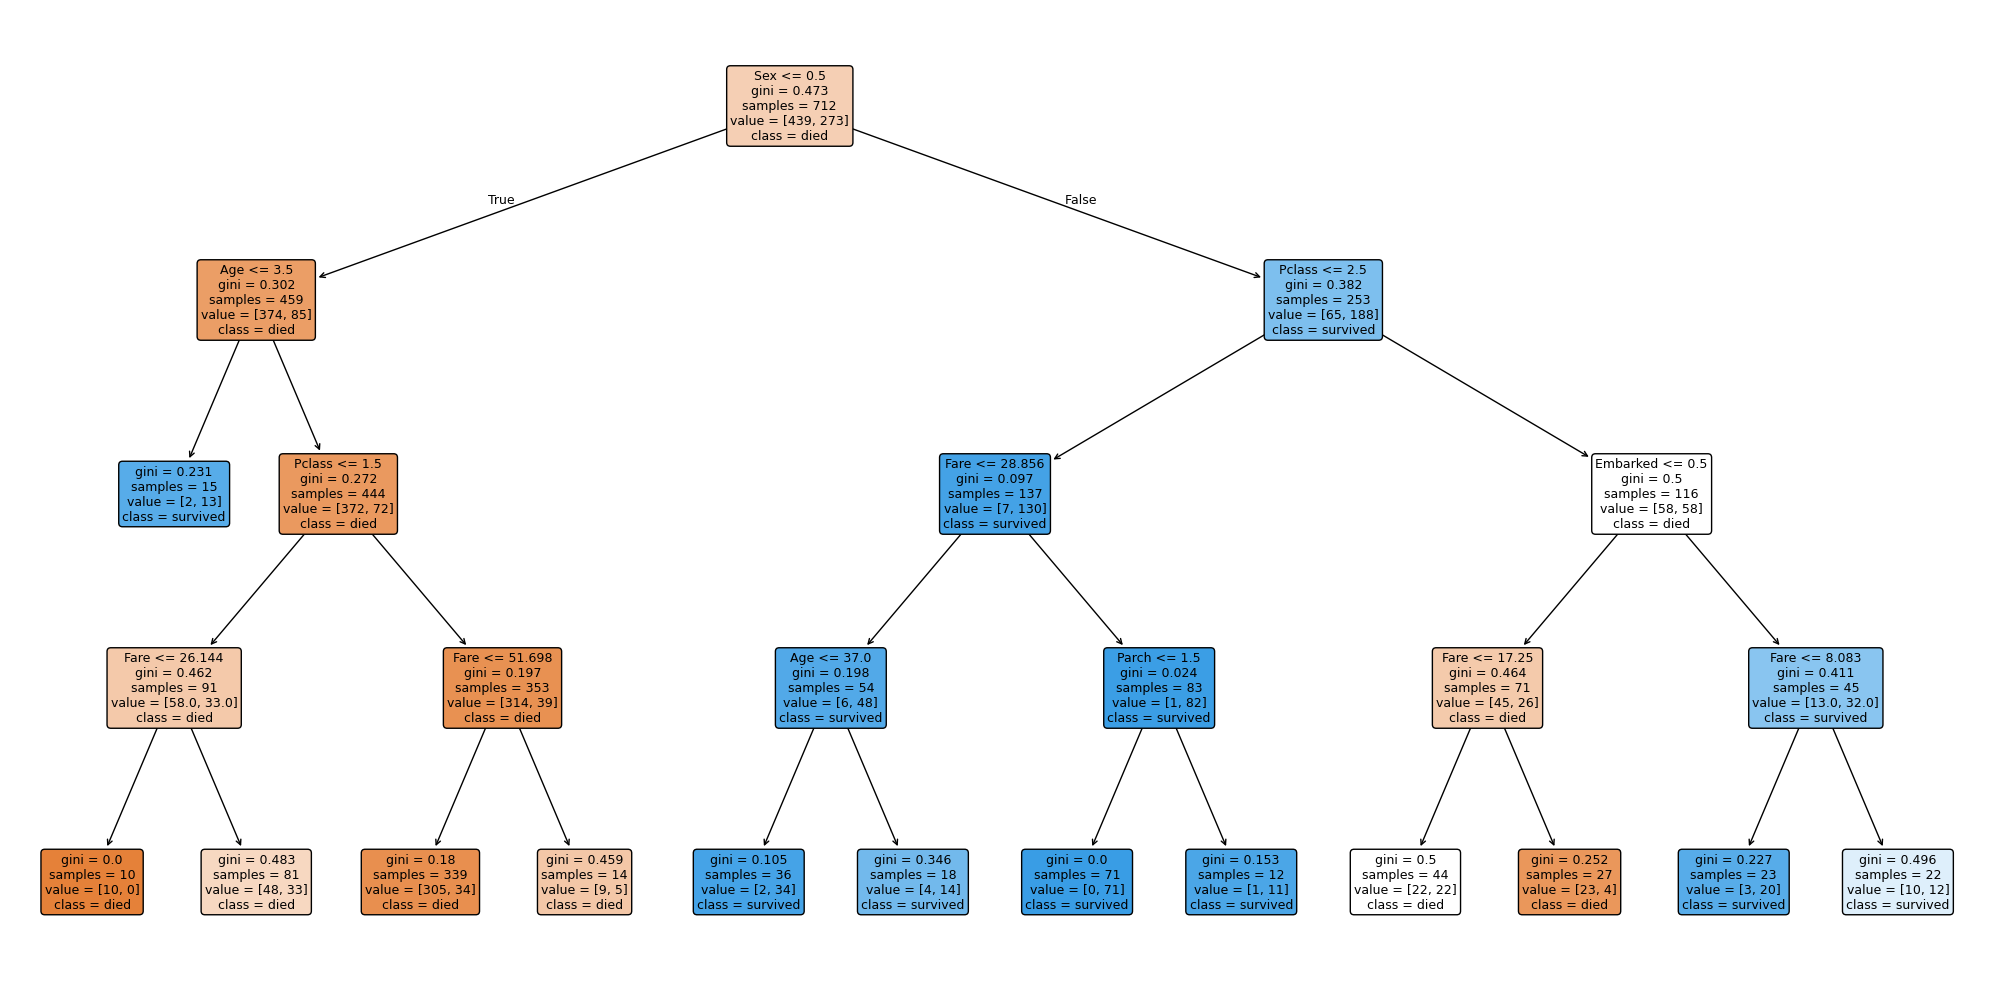

In [11]:
fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(
    clf, feature_names=features, class_names=["died", "survived"],
    filled=True, rounded=True, fontsize=9, ax=ax,
)
plt.tight_layout()
plt.show()

## 9. Interpretation
- **Sex is the dominant parameter.** The very first split is on sex: women are
  predicted to survive, men to die
- **Passenger class and fare come next**, separating the wealthier upper-class
  passengers (who had better deck access) from third-class passengers.